### Data Dependencies

In [12]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily) # smote
library(janitor)     # data cleaning
library(tidyverse) 

### Cleaning Data 

In [3]:
set.seed(100)

# ── 1. Load & Clean Column Names ──────────────────────────────────────────
merged <- read_csv("data/merged_data.csv", show_col_types = FALSE) |> 
  clean_names()

# ── 2. Train/test split ────────────────────────────────────────────────────
strata <- ifelse(merged$outbreak > 0, "nonzero", "zero")
index  <- createDataPartition(strata, p = 0.75, list = FALSE)
train  <- merged[index, ]
test   <- merged[-index, ]

# ── 3. Drop county and >50% NA columns ────────────────────────────────────
train <- train[, !names(train) %in% c("county")]
train <- train[, colMeans(is.na(train)) < 0.5]

# ── 4. Ensure all columns are numeric ─────────────────────────────────────
non_num <- names(train)[!sapply(train, is.numeric)]
if (length(non_num) > 0) {
  train[non_num] <- lapply(train[non_num], as.numeric)
}

# ── 5. Impute remaining NAs with column medians ────────────────────────────
train <- train |>
  mutate(across(
    .cols = everything(),
    .fns  = ~ifelse(is.na(.), median(., na.rm = TRUE), .)
  ))

stopifnot(sum(is.na(train)) == 0)

# Save train medians for test imputation (avoids leakage)
train_medians <- sapply(train[, names(train) != "outbreak"], median, na.rm = TRUE)

# ── 6. Mirror same cleaning on test set ───────────────────────────────────
test <- test[, names(test) %in% c(names(train), "outbreak")]

non_num_test <- names(test)[!sapply(test, is.numeric) & names(test) != "outbreak"]
if (length(non_num_test) > 0) {
  test[non_num_test] <- lapply(test[non_num_test], as.numeric)
}

test <- test |>
  mutate(across(
    .cols = -outbreak,
    .fns  = ~ifelse(is.na(.), train_medians[cur_column()], .)
  ))

test$outbreak <- as.numeric(test$outbreak)

stopifnot(sum(is.na(test)) == 0)

cat("Train rows:", nrow(train), "| Cols:", ncol(train), "\n")
cat("Test rows:",  nrow(test),  "| Cols:", ncol(test),  "\n")

# ── 7. Export for Python ───────────────────────────────────────────────────
write_csv(train, "data/created/train_clean.csv")
write_csv(test,  "data/created/test_clean.csv")

Train rows: 191 | Cols: 336 
Test rows: 63 | Cols: 336 


### SMOGN in Python

In [ ]:
import pandas as pd
import numpy as np
import smogn

# ── 1. Load cleaned train data from R ─────────────────────────────────────
train = pd.read_csv("data/created/train_clean.csv")

'''
print("Outbreak distribution before SMOGN:")
print(train["outbreak"].value_counts().sort_index())
print("Train shape:", train.shape)

# ── 2. Inspect outbreak range to set control points ───────────────────────
print("\nOutbreak summary:")
print(train["outbreak"].describe())
'''

# ── 3. Apply SMOGN with manual relevance control points ───────────────────
# rel_ctrl_pts_rg format: [[x, y, derivative], ...]
# x = outbreak value, y = relevance (0 = common, 1 = rare)
# Set low outbreak counts as common (0) and high counts as rare (1)

train_balanced = smogn.smoter(
    data          = train,
    y             = "outbreak",
    k             = 5,
    samp_method   = "balance",
    rel_thres     = 0.5,
    rel_method    = "manual",
    rel_ctrl_pts_rg = [
        [0, 0, 0],
        [2, 1, 0]   # mean = is uncommon
    ]
)

print("\nOutbreak distribution after SMOGN:")
print(train_balanced["outbreak"].value_counts().sort_index())
print("Train balanced shape:", train_balanced.shape)


# ── 4. Export balanced train set back for R modeling ──────────────────────
train_balanced.to_csv("data/created/train_balanced.csv", index=False)

### Initial testing of regression model using basic tree (No tuning)

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 69.1821 
MAE  (Mean Absolute Error)   : 23.4893 
R-squared                    : 0.0772 


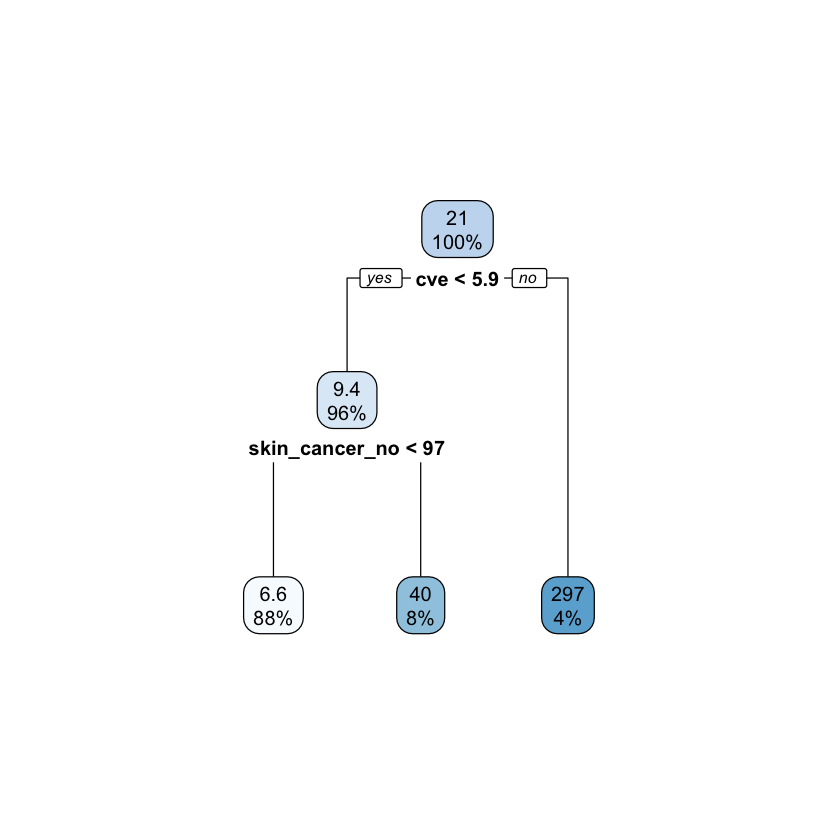

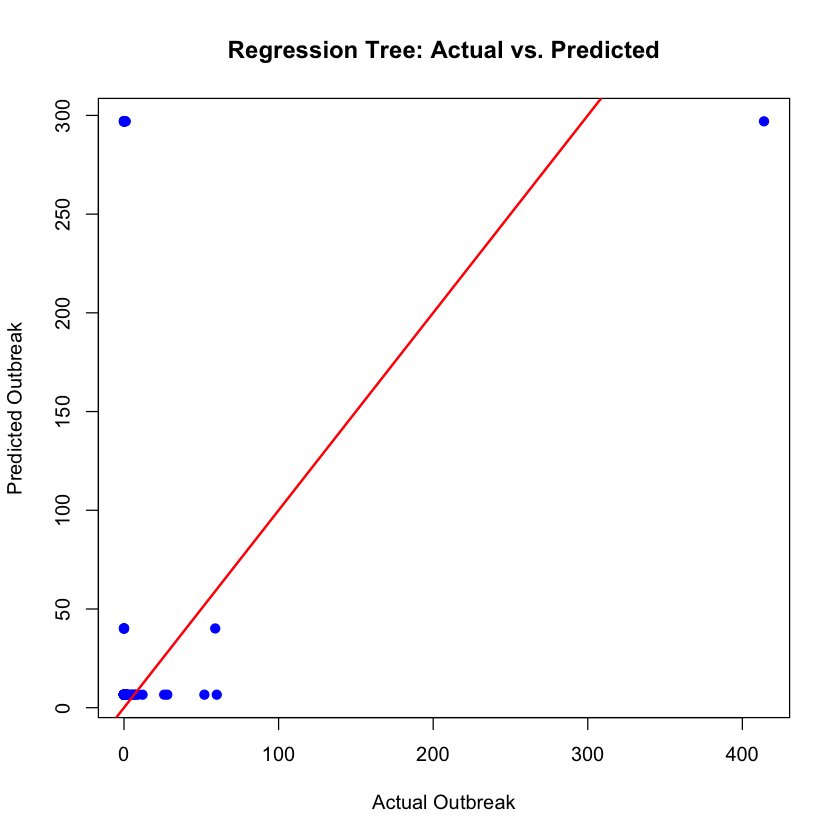

In [14]:
# Read data form CSV
train_balanced <- read_csv("data/created/train_balanced.csv", show_col_types = FALSE) 
test  <- read_csv("data/created/test_clean.csv", show_col_types = FALSE) 

# Train model 
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "anova")
rpart.plot(dtree_model)

# Eval Performance
predictions <- predict(dtree_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
rmse <- sqrt(mean((actual_values - predictions)^2))
mae  <- mean(abs(actual_values - predictions))
r2   <- cor(actual_values, predictions)^2

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)   :", round(mae, 4), "\n")
cat("R-squared                    :", round(r2, 4), "\n")

# Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree: Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line
